In [2]:
# Cell 1: Tiền xử lý dữ liệu và Ép Index cho Keras (Phiên bản đồng bộ File PKL)
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pickle

print("BƯỚC 1: LOAD DỮ LIỆU ĐÃ PRE-PROCESS CỦA BẢO")
print("=" * 60)

# 1. Đọc thẳng file dữ liệu Train/Test
train_df = pd.read_csv('../../Bảo/models/train_set.csv')
test_df = pd.read_csv('../../Bảo/models/test_set.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

# 2. Đọc file mapping (.pkl) để lấy chính xác kích thước Không gian Nhúng (Embedding)
with open('../../Bảo/models/user_to_index.pkl', 'rb') as f:
    user_to_index = pickle.load(f)
with open('../../Bảo/models/item_to_index.pkl', 'rb') as f:
    item_to_index = pickle.load(f)

num_users = len(user_to_index)
num_artists = len(item_to_index)

print(f"\nTổng số User trong từ điển: {num_users}")
print(f"Tổng số Artist trong từ điển: {num_artists}")

# 3. Trích xuất mảng dữ liệu đưa vào Keras (Bảo đã làm sẵn cột Index, chỉ việc dùng)
X_train_user = train_df['user_index'].values
X_train_artist = train_df['item_index'].values
y_train = train_df['rating'].values

X_test_user = test_df['user_index'].values
X_test_artist = test_df['item_index'].values
y_test = test_df['rating'].values

print("Hoàn tất chuẩn bị dữ liệu cho Lớp Nhúng (Embedding)!")
print("=" * 60)

BƯỚC 1: LOAD DỮ LIỆU ĐÃ PRE-PROCESS CỦA BẢO
Kích thước tập Train: (74267, 3)
Kích thước tập Test: (18567, 3)

Tổng số User trong từ điển: 1892
Tổng số Artist trong từ điển: 17632
Hoàn tất chuẩn bị dữ liệu cho Lớp Nhúng (Embedding)!


In [4]:
# Cell 2: Lắp ráp mạng Keras Matrix Factorization
print("BƯỚC 2: XÂY DỰNG KHUNG XƯƠNG MATRIX FACTORIZATION")
print("=" * 60)

LATENT_DIM = 32  # Đồng bộ tham số với cấu hình cơ sở của Bảo

# 1. Các cổng đầu vào (Input)
user_input = Input(shape=(1,), name='user_input')
artist_input = Input(shape=(1,), name='artist_input')

# 2. Lớp Nhúng (Embedding) - Biến ID thành Vector 32 chiều
user_embedding = Embedding(input_dim=num_users, output_dim=LATENT_DIM, name='user_embedding')(user_input)
user_vec = Flatten(name='flatten_user')(user_embedding)

artist_embedding = Embedding(input_dim=num_artists, output_dim=LATENT_DIM, name='artist_embedding')(artist_input)
artist_vec = Flatten(name='flatten_artist')(artist_embedding)

# 3. Tích vô hướng (Dot Product)
dot_product = Dot(axes=1, name='dot_product')([user_vec, artist_vec])

# 4. Biên dịch mô hình
model = Model(inputs=[user_input, artist_input], outputs=dot_product)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Hiển thị bản thiết kế kiến trúc
model.summary()
print("=" * 60)

BƯỚC 2: XÂY DỰNG KHUNG XƯƠNG MATRIX FACTORIZATION


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ artist_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │     60,544 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ artist_embedding    │ (None, 1, 32)     │    564,224 │ artist_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_user        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_artist      │ (None, 32)        │          0 │ artist_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1)         │          0 │ flatten_user[0][… │
│                     │                   │            │ flatten_artist[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 624,768 (2.38 MB)

 Trainable params: 624,768 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ (EPOCHS=5)
Epoch 1/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 10.9864 - val_loss: 10.8757
Epoch 2/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.1829 - val_loss: 8.8398
Epoch 3/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.9604 - val_loss: 5.5090
Epoch 4/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.2567 - val_loss: 3.8296
Epoch 5/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.8478 - val_loss: 3.0295


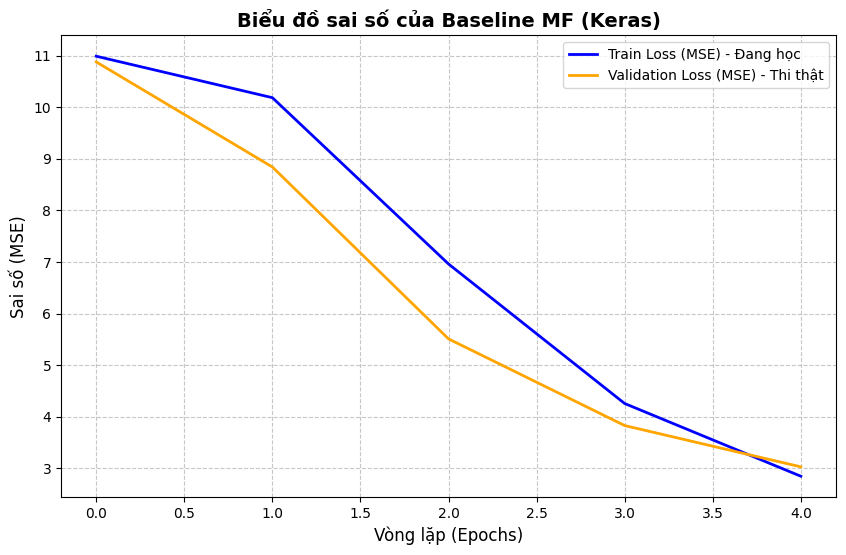

In [5]:
# Cell 3: Huấn luyện và theo dõi Validation Loss
print("BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ (EPOCHS=5)")
print("=" * 60)

# Tiến hành huấn luyện (Dùng X_test làm giám khảo)
history = model.fit(
    x=[X_train_user, X_train_artist],
    y=y_train,
    validation_data=([X_test_user, X_test_artist], y_test),
    epochs=5,           # Chỉ chạy thử 5 vòng trên Local
    batch_size=256,     # Xử lý 256 mẫu một lúc
    verbose=1           # Hiển thị thanh tiến trình
)

# Vẽ biểu đồ trực quan xem có bị học vẹt không
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (MSE) - Đang học', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE) - Thi thật', color='orange', linewidth=2)
plt.title('Biểu đồ sai số của Baseline MF (Keras)', fontsize=14, fontweight='bold')
plt.xlabel('Vòng lặp (Epochs)', fontsize=12)
plt.ylabel('Sai số (MSE)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Cell 4: Xây dựng hàm Gợi ý Top 10 (Inference)
print("BƯỚC 4: DỰ ĐOÁN TOP 10 NGHỆ SĨ CHO USER")
print("=" * 60)

# 1. Tạo từ điển dịch ngược (Từ Index số -> ID thật) để in ra màn hình
index_to_item = {index: item_id for item_id, index in item_to_index.items()}

def get_recommendations(user_id_that, top_n=10):
    # Kiểm tra xem user có tồn tại trong từ điển của Bảo không
    if user_id_that not in user_to_index:
        return "User không tồn tại trong hệ thống!"

    user_idx = user_to_index[user_id_that]

    # Lấy toàn bộ danh sách Artist Index (từ 0 đến 17631)
    all_artist_indices = np.array(list(item_to_index.values()))
    
    # Tạo một mảng chứa ID của User lặp lại 17632 lần để ghép cặp
    user_indices_array = np.array([user_idx] * len(all_artist_indices))

    # Dùng mô hình Keras để chấm điểm đồng loạt
    predicted_ratings = model.predict([user_indices_array, all_artist_indices], verbose=0).flatten()

    # Đưa kết quả vào bảng Pandas để dễ sắp xếp
    results = pd.DataFrame({
        'artist_index': all_artist_indices,
        'predicted_rating': predicted_ratings
    })

    # Sắp xếp điểm từ cao xuống thấp và cắt lấy Top N
    top_results = results.sort_values(by='predicted_rating', ascending=False).head(top_n)

    # Dịch ngược Index thành ID thật của Artist
    top_results['artistID_thật'] = top_results['artist_index'].map(index_to_item)

    return top_results[['artistID_thật', 'predicted_rating']]

# 2. Thử nghiệm ngay với User ID thật đầu tiên trong từ điển
sample_user = list(user_to_index.keys())[0]

print(f"Đang tính toán AI cho User ID: {sample_user}...")
top_10 = get_recommendations(sample_user, top_n=10)

print("\n--- KẾT QUẢ TOP 10 GỢI Ý ---")
print(top_10.to_string(index=False))
print("=" * 60)